# Apnea detection: dilated residual 1D CNN

Trains on the one-minute ECG windows in `data/processed/` and writes `model.keras`,
`history.json` and `training_curves.png` to `results/`.

## Setup

In [78]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import roc_auc_score, roc_curve
from tensorflow.keras import layers
from tensorflow.keras.models import Model

ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = RESULTS_DIR / "model.keras"
HISTORY_PATH = RESULTS_DIR / "history.json"
CURVES_PATH = RESULTS_DIR / "training_curves.png"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Hyperparameters

In [79]:
FS = 100
WINDOW_SAMPLES = 60 * FS

STEM = (
    #  filt  ker  str  pool
    (16,     15,   2,   1),
    (24,      7,   1,   2),
    (40,      7,   1,   2),
    (64,      5,   1,   2),
)

TRUNK_FILTERS = 32
TRUNK_KERNEL = 3
DILATIONS = (1, 2, 4, 8, 16, 32, 64)
SE_RATIO = 8
DROPOUT_TRUNK = 0.10
DROPOUT_HEAD = 0.30

EPOCHS = 70
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EARLY_STOP_PATIENCE = 12
REDUCE_LR_PATIENCE = 6

## Data

In [80]:
def load_split(split: str):
    X = np.load(PROCESSED_DIR / f"X_{split}_apnea.npy")
    y = np.load(PROCESSED_DIR / f"y_{split}_apnea.npy")
    assert len(X) == len(y), f"{split}: X and y disagree"
    return X[..., np.newaxis], y


X_tr, y_tr = load_split("train")
X_val, y_val = load_split("val")
print(f"train {X_tr.shape}  apnea {y_tr.mean():.1%}")
print(f"val   {X_val.shape}  apnea {y_val.mean():.1%}")

train (13158, 6000, 1)  apnea 40.1%
val   (3865, 6000, 1)  apnea 31.8%


## Model

In [81]:
def receptive_field() -> tuple[int, int]:
    span, stride = 1, 1
    for _filters, kernel, conv_stride, pool in STEM:
        span += (kernel - 1) * stride
        stride *= conv_stride
        if pool > 1:
            span += (pool - 1) * stride
            stride *= pool
    for dilation in DILATIONS:
        effective_kernel = 1 + (TRUNK_KERNEL - 1) * dilation
        span += 2 * (effective_kernel - 1) * stride
    return span, stride


def squeeze_excite(x, ratio: int, name: str):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling1D(name=f"{name}_se_squeeze")(x)
    se = layers.Dense(max(filters // ratio, 4), activation="relu", name=f"{name}_se_reduce")(se)
    se = layers.Dense(filters, activation="sigmoid", name=f"{name}_se_expand")(se)
    se = layers.Reshape((1, filters), name=f"{name}_se_reshape")(se)
    return layers.Multiply(name=f"{name}_se_scale")([x, se])


def conv_bn(x, filters: int, kernel: int, conv_name: str, bn_name: str,
            dilation: int = 1, strides: int = 1):
    x = layers.Conv1D(filters, kernel, strides=strides, padding="same", dilation_rate=dilation,
                      use_bias=False, name=conv_name)(x)
    return layers.BatchNormalization(name=bn_name)(x)


def residual_block(x, filters: int, kernel: int, dilation: int, dropout: float, name: str):
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = conv_bn(x, filters, 1, f"{name}_proj", f"{name}_proj_bn")

    y = conv_bn(x, filters, kernel, f"{name}_conv1", f"{name}_bn1", dilation)
    y = layers.Activation("relu", name=f"{name}_relu1")(y)
    y = layers.SpatialDropout1D(dropout, name=f"{name}_drop")(y)
    y = conv_bn(y, filters, kernel, f"{name}_conv2", f"{name}_bn2", dilation)
    y = squeeze_excite(y, SE_RATIO, name)

    y = layers.Add(name=f"{name}_add")([shortcut, y])
    return layers.Activation("relu", name=f"{name}_out")(y)


def attention_pool(x, name: str = "attn"):
    scores = layers.Conv1D(1, 1, name=f"{name}_score")(x)
    weights = layers.Softmax(axis=1, name=f"{name}_softmax")(scores)
    pooled = layers.Dot(axes=1, name=f"{name}_pool")([x, weights])
    return layers.Flatten(name=f"{name}_flat")(pooled)

In [82]:
def build_model(input_length: int = WINDOW_SAMPLES) -> Model:
    span, _stride = receptive_field()
    assert span >= input_length, (
        f"receptive field {span} samples ({span / FS:.2f} s) does not cover "
        f"the {input_length}-sample window")

    inputs = layers.Input(shape=(input_length, 1), name="ecg")

    x = inputs
    for i, (filters, kernel, conv_stride, pool) in enumerate(STEM, start=1):
        if i == len(STEM):
            filters = TRUNK_FILTERS
        x = conv_bn(x, filters, kernel, f"stem{i}_conv", f"stem{i}_bn", strides=conv_stride)
        x = layers.Activation("relu", name=f"stem{i}_relu")(x)
        if pool > 1:
            x = layers.MaxPooling1D(pool, name=f"stem{i}_pool")(x)

    for i, dilation in enumerate(DILATIONS, start=1):
        x = residual_block(x, TRUNK_FILTERS, TRUNK_KERNEL, dilation, DROPOUT_TRUNK,
                           name=f"block{i}_d{dilation}")

    pooled = layers.Concatenate(name="pool_concat")([
        attention_pool(x),
        layers.GlobalAveragePooling1D(name="avg_pool")(x),
        layers.GlobalMaxPooling1D(name="max_pool")(x),
    ])

    y = layers.Dense(64, activation="relu", name="head_dense")(pooled)
    y = layers.Dropout(DROPOUT_HEAD, name="head_drop")(y)
    outputs = layers.Dense(1, activation="sigmoid", name="apnea_prob")(y)

    return Model(inputs, outputs, name="apnea_dilated_cnn")


model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy",
             tf.keras.metrics.AUC(name="auc"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.Precision(name="precision")],
)
model.summary()

Model: "apnea_dilated_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg (InputLayer)    │ (None, 6000, 1)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_conv (Conv1D) │ (None, 3000, 16)  │        240 │ ecg[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_bn            │ (None, 3000, 16)  │         64 │ stem1_conv[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_relu          │ (None, 3000, 16)  │          0 │ stem1_bn[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_conv (Conv1D) │ (None, 3000, 24)  │      2,688 │ stem1_relu[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_bn            │ (None, 3000, 24)  │         96 │ stem2_conv[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_relu          │ (None, 3000, 24)  │          0 │ stem2_bn[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_pool          │ (None, 1500, 24)  │          0 │ stem2_relu[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem3_conv (Conv1D) │ (None, 1500, 40)  │      6,720 │ stem2_pool[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem3_bn            │ (None, 1500, 40)  │        160 │ stem3_conv[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem3_relu          │ (None, 1500, 40)  │          0 │ stem3_bn[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem3_pool          │ (None, 750, 40)   │          0 │ stem3_relu[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem4_conv (Conv1D) │ (None, 750, 32)   │      6,400 │ stem3_pool[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem4_bn            │ (None, 750, 32)   │        128 │ stem4_conv[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem4_relu          │ (None, 750, 32)   │          0 │ stem4_bn[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem4_pool          │ (None, 375, 32)   │          0 │ stem4_relu[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_d1_conv1     │ (None, 375, 32)   │      3,072 │ stem4_pool[0][0]  │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_d1_bn1       │ (None, 375, 32)   │        128 │ block1_d1_conv1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 69,646 (272.05 KB)

 Trainable params: 68,526 (267.68 KB)

 Non-trainable params: 1,120 (4.38 KB)

## Training

In [83]:
class LearningRateLog(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs is not None:
            logs["lr"] = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))


train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
            .shuffle(len(y_tr), seed=SEED, reshuffle_each_iteration=True)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

history = model.fit(
    train_ds,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    shuffle=False,
    callbacks=[
        LearningRateLog(),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=EARLY_STOP_PATIENCE,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc", mode="max", factor=0.5,
            patience=REDUCE_LR_PATIENCE, min_lr=1e-6, verbose=1),
    ],
    verbose=1,
)

Epoch 1/70
206/206 ━━━━━━━━━━━━━━━━━━━━ 85s 349ms/step - accuracy: 0.7886 - auc: 0.8622 - loss: 0.4659 - precision: 0.7406 - recall: 0.7282 - val_accuracy: 0.6820 - val_auc: 0.7554 - val_loss: 0.8994 - val_precision: 1.0000 - val_recall: 0.0016 - lr: 0.0010 - learning_rate: 0.0010
Epoch 2/70
206/206 ━━━━━━━━━━━━━━━━━━━━ 77s 376ms/step - accuracy: 0.8839 - auc: 0.9511 - loss: 0.2783 - precision: 0.8545 - recall: 0.8564 - val_accuracy: 0.7863 - val_auc: 0.8466 - val_loss: 0.5012 - val_precision: 0.7425 - val_recall: 0.5037 - lr: 0.0010 - learning_rate: 0.0010
Epoch 3/70
206/206 ━━━━━━━━━━━━━━━━━━━━ 71s 346ms/step - accuracy: 0.9032 - auc: 0.9634 - loss: 0.2396 - precision: 0.8815 - recall: 0.8765 - val_accuracy: 0.8261 - val_auc: 0.8946 - val_loss: 0.4738 - val_precision: 0.6887 - val_recall: 0.8286 - lr: 0.0010 - learning_rate: 0.0010
Epoch 4/70
206/206 ━━━━━━━━━━━━━━━━━━━━ 69s 336ms/step - accuracy: 0.9147 - auc: 0.9701 - loss: 0.2167 - precision: 0.8939 - recall: 0.8934 - val_accuracy

## Save

In [84]:
model.save(MODEL_PATH)

record = {k: [float(v) for v in vals] for k, vals in history.history.items()}
HISTORY_PATH.write_text(json.dumps(record, indent=1))

print(f"saved {MODEL_PATH}")
print(f"saved {HISTORY_PATH}")

saved /Users/adhambouras/Documents/Github/ENSAM_APNEA_CNN/results/model.keras
saved /Users/adhambouras/Documents/Github/ENSAM_APNEA_CNN/results/history.json


## Training curves

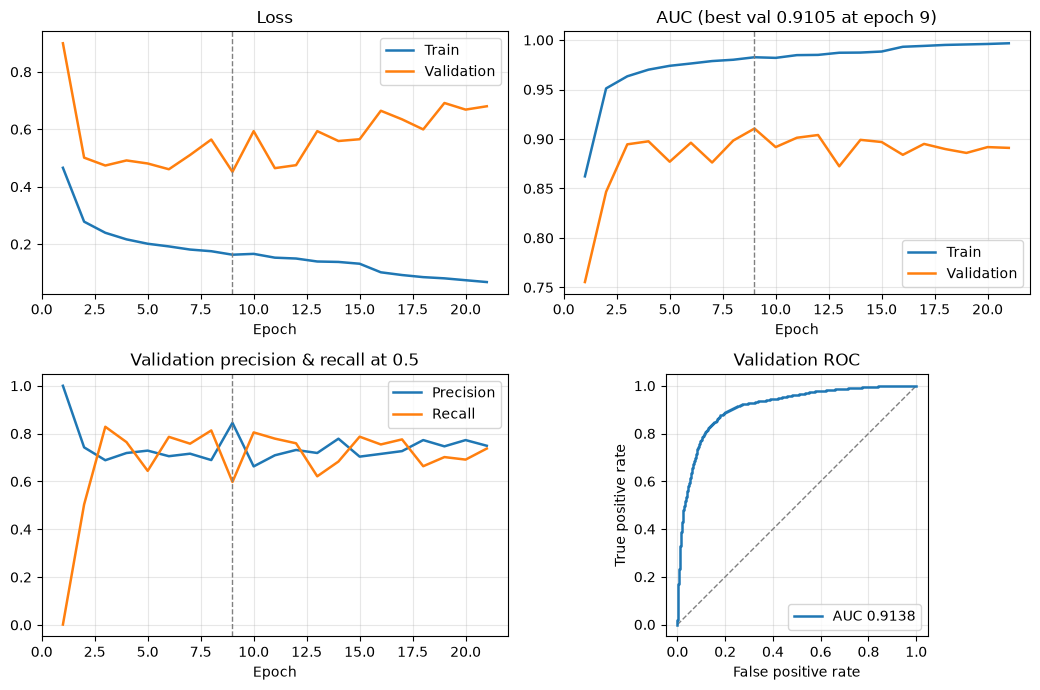

saved /Users/adhambouras/Documents/Github/ENSAM_APNEA_CNN/results/training_curves.png


In [85]:
prob_val = model.predict(X_val, verbose=0).ravel()
epochs = np.arange(1, len(record["loss"]) + 1)
best = int(np.argmax(record["val_auc"])) + 1

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7))
panels = [
    (axes[0, 0], "Loss", [("Train", "loss"), ("Validation", "val_loss")]),
    (axes[0, 1], f"AUC (best val {max(record['val_auc']):.4f} at epoch {best})",
     [("Train", "auc"), ("Validation", "val_auc")]),
    (axes[1, 0], "Validation precision & recall at 0.5",
     [("Precision", "val_precision"), ("Recall", "val_recall")]),
]
for ax, title, series in panels:
    for label, key in series:
        ax.plot(epochs, record[key], label=label, linewidth=1.8)
    ax.axvline(best, color="grey", linestyle="--", linewidth=1)
    ax.set(title=title, xlabel="Epoch")
    ax.grid(alpha=0.3)
    ax.legend()

fpr, tpr, _ = roc_curve(y_val, prob_val)
ax = axes[1, 1]
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1)
ax.plot(fpr, tpr, linewidth=1.8, label=f"AUC {roc_auc_score(y_val, prob_val):.4f}")
ax.set(title="Validation ROC", xlabel="False positive rate", ylabel="True positive rate")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.3)
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(CURVES_PATH, dpi=150)
plt.show()
print(f"saved {CURVES_PATH}")

## TensorFlow Lite conversion

Converts `results/model.keras` into a fully int8 model for TFLite Micro on the ESP32-S3.

- **Fixed input shape `(1, 6000, 1)`**: a microcontroller allocates every tensor up front.
- **Full int8**: weights, activations, input and output. Activation ranges are calibrated on
  500 real training windows.
- The model is exported as a SavedModel first. Converting the Keras 3 object directly leaves the
  weights as variables, and int8 calibration then fails.

Only needs the Setup, Hyperparameters and Data cells; it does not need retraining.

In [86]:
import tempfile

TFLITE_PATH = RESULTS_DIR / "model_int8.tflite"

model = tf.keras.models.load_model(MODEL_PATH)


def representative_dataset():
    rng = np.random.default_rng(SEED)
    for i in rng.choice(len(X_tr), size=500, replace=False):
        yield [X_tr[i:i + 1]]


with tempfile.TemporaryDirectory() as saved_model_dir:
    model.export(saved_model_dir, format="tf_saved_model", verbose=False,
                 input_signature=[tf.TensorSpec([1, WINDOW_SAMPLES, 1], tf.float32, name="ecg")])

    converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    tflite_model = converter.convert()

TFLITE_PATH.write_bytes(tflite_model)
print(f"saved {TFLITE_PATH} ({len(tflite_model) / 1024:.1f} KB)")

W0000 00:00:1790086557.593902   11451 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790086557.594163   11451 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


saved /Users/adhambouras/Documents/Github/ENSAM_APNEA_CNN/results/model_int8.tflite (124.5 KB)


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## Check the int8 model against Keras

Runs the `.tflite` file on the validation records, one window at a time as the device does, and
compares it with the Keras model.

In [87]:
import warnings

warnings.filterwarnings("ignore", message=".*tf.lite.Interpreter is deprecated.*")

interpreter = tf.lite.Interpreter(
    model_content=tflite_model,
    experimental_op_resolver_type=tf.lite.experimental.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES)
# Plain built-in kernels: the desktop XNNPACK delegate cannot prepare this int8
# graph, and the reference kernels are closer to what TFLite Micro runs.
interpreter.allocate_tensors()

inp, out = interpreter.get_input_details()[0], interpreter.get_output_details()[0]
in_scale, in_zero = inp["quantization"]
out_scale, out_zero = out["quantization"]


def predict_int8(X):
    probs = np.empty(len(X), dtype=np.float32)
    for i, x in enumerate(X):
        q = np.clip(np.round(x / in_scale) + in_zero, -128, 127).astype(np.int8)
        interpreter.set_tensor(inp["index"], q[np.newaxis])
        interpreter.invoke()
        probs[i] = (int(interpreter.get_tensor(out["index"])[0, 0]) - out_zero) * out_scale
    return probs


prob_keras = model.predict(X_val, verbose=0).ravel()
prob_int8 = predict_int8(X_val)

ops = sorted({op["op_name"] for op in interpreter._get_ops_details()})
print(f"operators ({len(ops)}): {', '.join(ops)}")
print(f"input  int8: scale {in_scale:.6f}, zero point {in_zero}")
print(f"output int8: scale {out_scale:.6f}, zero point {out_zero}\n")
print(f"validation AUC   Keras {roc_auc_score(y_val, prob_keras):.4f}   int8 {roc_auc_score(y_val, prob_int8):.4f}")
gap = np.abs(prob_keras - prob_int8)
print(f"|P(keras) - P(int8)|: mean {gap.mean():.4f}, 99th percentile {np.percentile(gap, 99):.4f}, max {gap.max():.4f}")
print(f"same decision at 0.5 on {np.mean((prob_keras > 0.5) == (prob_int8 > 0.5)):.2%} of minutes")

operators (12): ADD, BATCH_MATMUL, CONCATENATION, CONV_2D, FULLY_CONNECTED, LOGISTIC, MAX_POOL_2D, MEAN, MUL, REDUCE_MAX, RESHAPE, SOFTMAX
input  int8: scale 0.130436, zero point 15
output int8: scale 0.003906, zero point -128

validation AUC   Keras 0.9138   int8 0.9128
|P(keras) - P(int8)|: mean 0.0150, 99th percentile 0.1237, max 0.3127
same decision at 0.5 on 99.35% of minutes
